Library Import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("ALL LIBRARIES LOADED!")

ALL LIBRARIES LOADED!


Dataset load

In [5]:
df = pd.read_csv('data/online_retail_II.csv')

print(f"DATA LOADED SUCCESSFULLY!\n")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

DATA LOADED SUCCESSFULLY!

Total Rows: 227,381
Total Columns: 9

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalAmount']


Data Preview

In [6]:
print("1ST 5 DATA OF THE DATASET")
df.head()

1ST 5 DATA OF THE DATASET


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00


Dataset Summary

In [7]:
print("DATASET SUMMARY")
print(f"\nData Shape: {df.shape}")
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nData Types:")
print(df.dtypes)

DATASET SUMMARY

Data Shape: (227381, 9)

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalAmount    0
dtype: int64

Data Types:
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
TotalAmount    float64
dtype: object


Data Cleaning

In [8]:
rows_before = len(df)
print("DATA CLEANING STARTED:")

print(f"\nRows before cleaning: {rows_before:,}")

# Step 1: Remove Missing Values
print("\nRemoving missing values...")
df = df.dropna(subset=['Customer ID'])
df = df.dropna(subset=['Description'])
print(f"  Rows after removing missing values: {len(df):,}")

# Step 2: Remove Cancelled Orders
print("\nRemoving cancelled orders...")
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"  Rows after removing cancellations: {len(df):,}")

# Step 3: Remove Invalid Quantity & Price
print("\nRemoving invalid Quantity & Price...")
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print(f"  Rows after removing invalid values: {len(df):,}")

# Step 4: Remove Non-Product StockCodes
print("\nRemoving non-product StockCodes...")
non_product_codes = ['POST', 'D', 'M', 'BANK CHARGES',
                     'PADS', 'DOT', 'CRUK', 'S', 'AMAZONFEE']
before_step4 = len(df)
df = df[~df['StockCode'].astype(str).isin(non_product_codes)]
print(f"  Removed: {before_step4 - len(df):,} non-product rows")
print(f"  Rows remaining: {len(df):,}")

# Step 5: Remove Duplicate Rows
print("\nRemoving duplicate rows...")
before_step5 = len(df)
df = df.drop_duplicates(
    subset=['Invoice', 'StockCode', 'Customer ID', 'InvoiceDate']
)
print(f"  Removed: {before_step5 - len(df):,} duplicate rows")
print(f"  Rows remaining: {len(df):,}")

# Step 6: Remove Outliers
print("\nRemoving extreme outliers (> 99.9th percentile)...")
before_step6 = len(df)
df = df[df['Quantity']    <= df['Quantity'].quantile(0.999)]
df = df[df['Price']       <= df['Price'].quantile(0.999)]
print(f"  Removed: {before_step6 - len(df):,} outlier rows")
print(f"  Rows remaining: {len(df):,}")

# Step 7: Fix Data Types
print("\nFixing data types...")
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"  Customer ID → int")
print(f"  InvoiceDate → datetime")

# Step 8: Country Standardization
print("\nStandardizing country names...")
country_mapping = {
    'EIRE':                 'Ireland',
    'Channel Islands':      'United Kingdom',
    'RSA':                  'South Africa',
    'West Indies':          'Caribbean',
    'European Community':   'Europe',
    'Unspecified':          'Unknown',
}
df['Country'] = df['Country'].replace(country_mapping)
print(f"  Unique countries: {df['Country'].nunique()} ")

# Step 9: Final Validation
print("\nFinal validation...")
assert df.isnull().sum().sum() == 0,   "Missing values found!"
assert (df['Quantity'] > 0).all(),     "Invalid Quantity found!"
assert (df['Price'] > 0).all(),        "Invalid Price found!"
assert (df['TotalAmount'] > 0).all(),  "Invalid TotalAmount found!"
print(f"  No missing values")
print(f"  All Quantity values positive")
print(f"  All Price values positive")
print(f"  All TotalAmount values positive")

rows_after = len(df)
print("   \nDATA CLEANING COMPLETE!\n")
print(f"  Rows before  : {rows_before:>10,}")
print(f"  Rows after   : {rows_after:>10,}")
print(f"  Rows removed : {rows_before - rows_after:>10,}")
print(f"  Data retained: {rows_after/rows_before*100:>9.1f}%")
print(f"  Missing Values: {df.isnull().sum().sum():>9}")

print("  READY FOR ANALYSIS!")

df.to_csv('data/online_retail_II.csv', index=False)
print(f"\nCLEAN DATASET SAVED!")
print(f"\nFirst 5 rows:")
display(df.head())

DATA CLEANING STARTED:

Rows before cleaning: 227,381

Removing missing values...
  Rows after removing missing values: 227,381

Removing cancelled orders...
  Rows after removing cancellations: 227,381

Removing invalid Quantity & Price...
  Rows after removing invalid values: 227,381

Removing non-product StockCodes...
  Removed: 1,895 non-product rows
  Rows remaining: 225,486

Removing duplicate rows...
  Removed: 4,447 duplicate rows
  Rows remaining: 221,039

Removing extreme outliers (> 99.9th percentile)...
  Removed: 413 outlier rows
  Rows remaining: 220,626

Fixing data types...
  Customer ID → int
  InvoiceDate → datetime

Standardizing country names...
  Unique countries: 14 

Final validation...
  No missing values
  All Quantity values positive
  All Price values positive
  All TotalAmount values positive
   
DATA CLEANING COMPLETE!

  Rows before  :    227,381
  Rows after   :    220,626
  Rows removed :      6,755
  Data retained:      97.0%
  Missing Values:         0

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


Clean Data Summary

In [12]:
print("CLEAN DATA SUMMARY:")

print(f"\nDataset Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range         : {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Unique Customers   : {df['Customer ID'].nunique():,}")
print(f"Unique Products    : {df['StockCode'].nunique():,}")
print(f"Unique Countries   : {df['Country'].nunique()}")

print("\nMissing Values:")
print(df.isnull().sum())

print(f"\nDuplicate Rows     : {df.duplicated().sum()}")

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head(5))

CLEAN DATA SUMMARY:

Dataset Shape      : 220,626 rows × 12 columns
Date Range         : 2009-12-01 to 2011-12-09
Unique Customers   : 5,414
Unique Products    : 3,365
Unique Countries   : 14

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalAmount    0
Month          0
DayOfWeek      0
Hour           0
dtype: int64

Duplicate Rows     : 0

Data Types:
Invoice                 int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
TotalAmount           float64
Month               period[M]
DayOfWeek                 str
Hour                    int32
dtype: object

First 5 Rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Month,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12,Tuesday,7


Sales Overview Chart

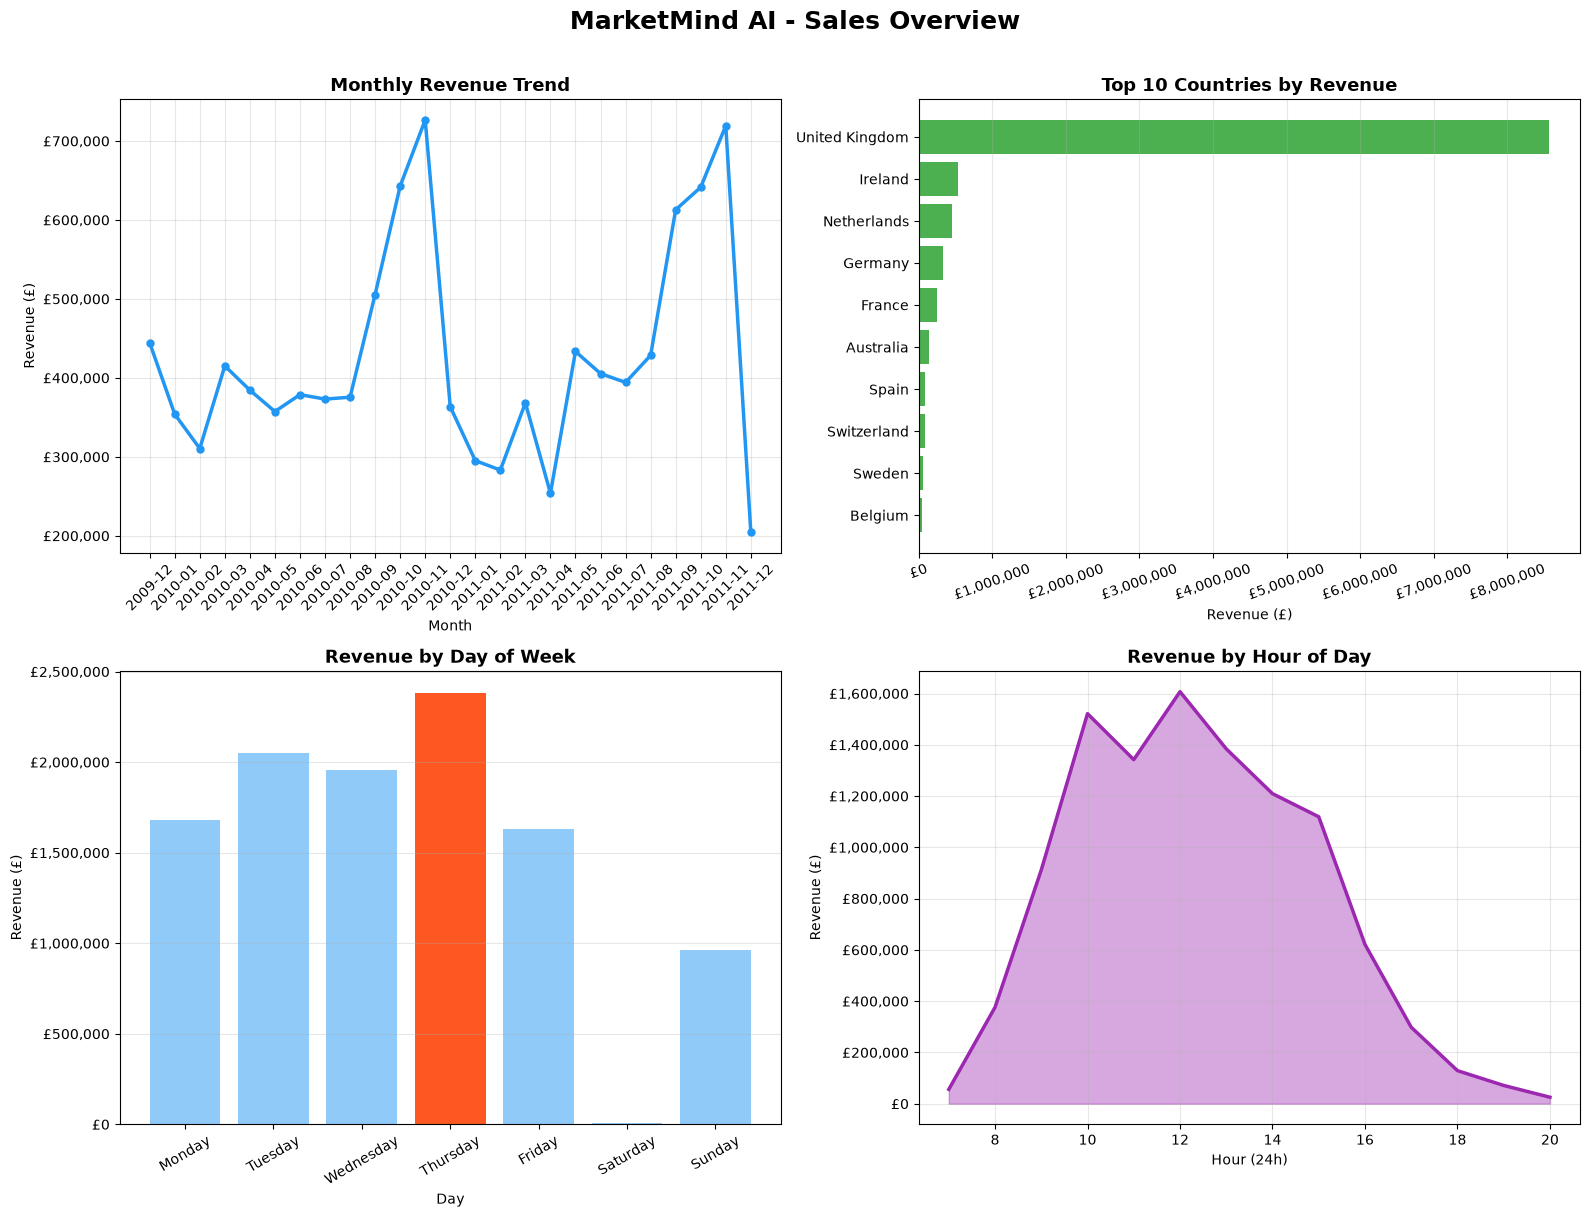

Sales Overview Chart saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MarketMind AI - Sales Overview', fontsize=18, fontweight='bold', y=1.01)

# Chart 1: Monthly Revenue Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['TotalAmount'].sum()
axes[0,0].plot(monthly_revenue.index.astype(str), monthly_revenue.values, 
               marker='o', color='#2196F3', linewidth=2.5, markersize=5)
axes[0,0].set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[0,0].grid(True, alpha=0.3)

# Chart 2: Top 10 Countries by Revenue
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(country_revenue.index[::-1], country_revenue.values[::-1], color='#4CAF50')
axes[0,1].set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Revenue (£)')
axes[0,1].tick_params(axis='x', rotation=20)
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[0,1].grid(True, alpha=0.3, axis='x')

# Chart 3: Revenue by Day of Week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_revenue = df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)
colors = ['#FF5722' if day == day_revenue.idxmax() else '#90CAF9' for day in day_order]
axes[1,0].bar(day_revenue.index, day_revenue.values, color=colors)
axes[1,0].set_title('Revenue by Day of Week', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Revenue (£)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[1,0].grid(True, alpha=0.3, axis='y')

# Chart 4: Revenue by Hour of Day
df['Hour'] = df['InvoiceDate'].dt.hour
hour_revenue = df.groupby('Hour')['TotalAmount'].sum()
axes[1,1].fill_between(hour_revenue.index, hour_revenue.values, alpha=0.4, color='#9C27B0')
axes[1,1].plot(hour_revenue.index, hour_revenue.values, color='#9C27B0', linewidth=2.5)
axes[1,1].set_title('Revenue by Hour of Day', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Hour (24h)')
axes[1,1].set_ylabel('Revenue (£)')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sales_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sales Overview Chart saved!")

Key Business Metrics / EDA Analysis

In [11]:
total_revenue = df['TotalAmount'].sum()
total_orders = df['Invoice'].nunique()
total_customers = df['Customer ID'].nunique()

avg_order_value = total_revenue / total_orders
avg_customer_value = total_revenue / total_customers

top_country = (
    df.groupby('Country')['TotalAmount']
      .sum()
      .idxmax()
)

best_month = monthly_revenue.idxmax()


print("KEY BUSINESS METRICS / EDA Analysis:\n")

print(f"Total Revenue          : £{total_revenue:,.2f}")
print(f"Total Orders           : {total_orders:,}")
print(f"Total Customers        : {total_customers:,}")
print(f"Average Order Value    : £{avg_order_value:,.2f}")
print(f"Average Customer Value : £{avg_customer_value:,.2f}")
print(f"Top Revenue Country    : {top_country}")
print(f"Best Sales Month       : {best_month}")

print("\nEDA Analysis Complete — Ready for RFM Analysis!")

KEY BUSINESS METRICS / EDA Analysis:

Total Revenue          : £10,673,082.68
Total Orders           : 31,709
Total Customers        : 5,414
Average Order Value    : £336.59
Average Customer Value : £1,971.39
Top Revenue Country    : United Kingdom
Best Sales Month       : 2010-11

EDA Analysis Complete — Ready for RFM Analysis!
